# xCounter — Análise Exploratória dos Dados (EDA)

**Disciplina:** COE609 — Ciência de Dados Aplicada ao Futebol (UFRJ, 2026.1)

Notebook **somente de exploração**. Examina o dataset pré-processado
`dados_processados/xcounter_features_unificado.csv` (contra-ataques de 5 competições
masculinas, com features espaciais 360 + físicas do FM) — antes de qualquer modelagem.

Objetivos: entender volume e balanceamento, distribuições das features, relação
com o alvo `sucesso`, correlações e qualidade dos dados (faltantes / match FM).

In [1]:
import os

# Executa a partir da raiz do projeto (este notebook fica em notebooks/)

if os.path.basename(os.getcwd()) == 'notebooks':

    os.chdir('..')

print('Diretório de trabalho:', os.getcwd())

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
print('Bibliotecas carregadas.')

Diretório de trabalho: C:\Users\lolfa\OneDrive\Área de Trabalho\Futebol + DS\COE609-2026.1
Bibliotecas carregadas.


## 1. Visão geral do dataset

In [2]:
DATA = 'dados_processados/xcounter_features_unificado.csv'
df = pd.read_csv(DATA, encoding='utf-8')

ESPACIAIS = ['dist_gol_defensor_proximo', 'dist_gol_atacante_avancado',
             'diferencial_profundidade', 'num_defensores_entre_bola_gol',
             'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo']
FISICAS   = ['pace_atacante', 'acceleration_atacante', 'stamina_atacante',
             'pace_defensor', 'acceleration_defensor',
             'diferencial_pace', 'diferencial_acceleration']

print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Competições: {df["competicao"].unique().tolist()}')
display(df.head())
display(df[ESPACIAIS + FISICAS].describe().T.round(2))

Dimensões: 642 linhas × 32 colunas
Competições: ['World Cup 2022', 'Euro 2020', 'La Liga 2020/21', 'Ligue 1 2021/22', 'Ligue 1 2022/23']


,id_inicio,player_name,team,minute,second,tipo_inicio,num_eventos,progressao_x,duracao_s,terminou_chute,...,atac_fm_nome,atac_fm_sim,atac_match_ok,pace_atacante,acceleration_atacante,stamina_atacante,pace_defensor,acceleration_defensor,diferencial_pace,diferencial_acceleration
0,020f02c0-eabb-425f-b251-cec1644c8d57,Alphonso Davies,Canada,13,55,Pass,18,103.9,12.0,True,...,Alphonso Davies,1.0,True,19.0,19.0,16.0,14.00,14.25,5.00,4.75
1,7dace1ef-5a84-4683-a8d8-1244ea3fab77,Mehdi Torabi,Iran,76,15,Pass,8,67.0,5.0,True,...,Mehdi Torabi,1.0,True,14.0,14.0,14.0,14.00,13.00,0.00,1.00
2,54e65e59-2683-49d3-9756-3935b016dafb,Timothy Castagne,Belgium,8,12,Pass,6,19.1,3.0,False,...,Timothy Castagne,1.0,True,15.0,15.0,15.0,15.00,13.50,0.00,1.50
3,cd15385d-9c10-418f-8f07-6783a27a4a5f,Andrej Kramarić,Croatia,9,9,Pass,7,36.0,4.0,False,...,Andrej Kramarić,1.0,True,13.0,14.0,16.0,12.25,11.25,0.75,2.75
4,90603b2c-649b-4859-973f-7ca53c47781f,Kevin De Bruyne,Belgium,12,47,Pass,10,90.1,9.0,True,...,Kevin De Bruyne,1.0,True,14.0,15.0,17.0,15.00,13.50,-1.00,1.50


,count,mean,std,min,25%,50%,75%,max
dist_gol_defensor_proximo,581.0,72.47,22.04,4.46,56.75,76.80,89.78,114.03
dist_gol_atacante_avancado,581.0,73.94,21.20,10.00,57.76,77.91,91.38,112.01
diferencial_profundidade,581.0,-1.85,6.67,-19.21,-6.04,-2.26,2.19,31.12
num_defensores_entre_bola_gol,581.0,4.23,1.99,0.00,3.00,4.00,6.00,10.00
largura_linha_defensiva,581.0,27.14,12.22,0.00,18.33,25.74,34.81,67.06
dist_bola_gol,581.0,89.51,20.29,10.00,75.19,94.50,105.22,122.15
superioridade_terco_ofensivo,581.0,-0.10,0.56,-3.00,0.00,0.00,0.00,3.00
pace_atacante,641.0,13.10,2.16,6.00,12.00,13.00,14.00,20.00
acceleration_atacante,641.0,12.79,2.25,6.00,12.00,13.00,14.00,20.00
stamina_atacante,641.0,13.39,2.63,1.00,12.00,14.00,15.00,20.00


## 2. Alvo (`sucesso`) — balanceamento geral e por competição

Taxa de sucesso geral: 15.1%  (97 de 642)


,n,sucessos,taxa
competicao,,,
Euro 2020,170,20,11.8
La Liga 2020/21,95,16,16.8
Ligue 1 2021/22,75,14,18.7
Ligue 1 2022/23,110,22,20.0
World Cup 2022,192,25,13.0


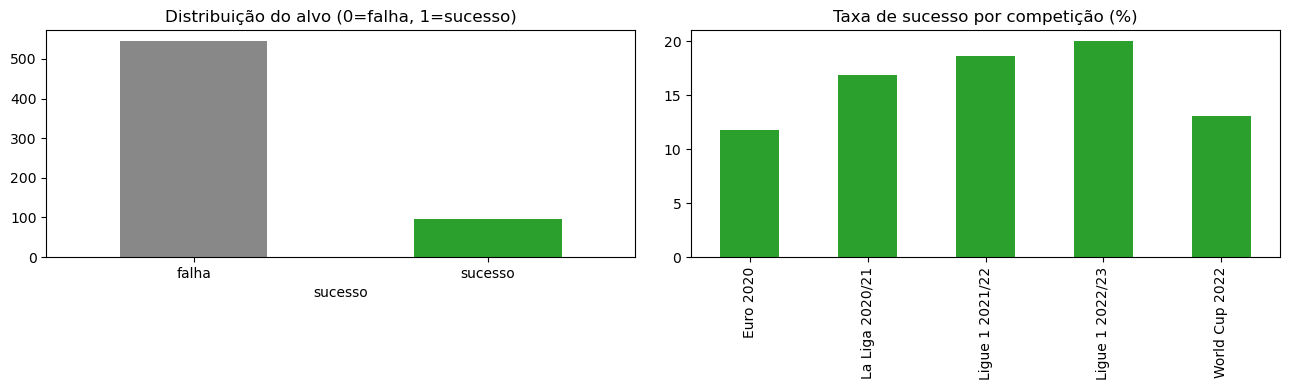

In [3]:
y = df['sucesso'].astype(int)
print(f'Taxa de sucesso geral: {y.mean():.1%}  ({int(y.sum())} de {len(y)})')

g = df.groupby('competicao')['sucesso'].agg(n='size', sucessos='sum', taxa='mean')
display(g.assign(taxa=(g['taxa'] * 100).round(1)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
y.value_counts().sort_index().plot.bar(ax=axes[0], color=['#888', '#2ca02c'])
axes[0].set_title('Distribuição do alvo (0=falha, 1=sucesso)')
axes[0].set_xticklabels(['falha', 'sucesso'], rotation=0)
(g['taxa'] * 100).plot.bar(ax=axes[1], color='#2ca02c')
axes[1].set_title('Taxa de sucesso por competição (%)'); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()

## 3. Distribuições das features

Histogramas das features espaciais e físicas.

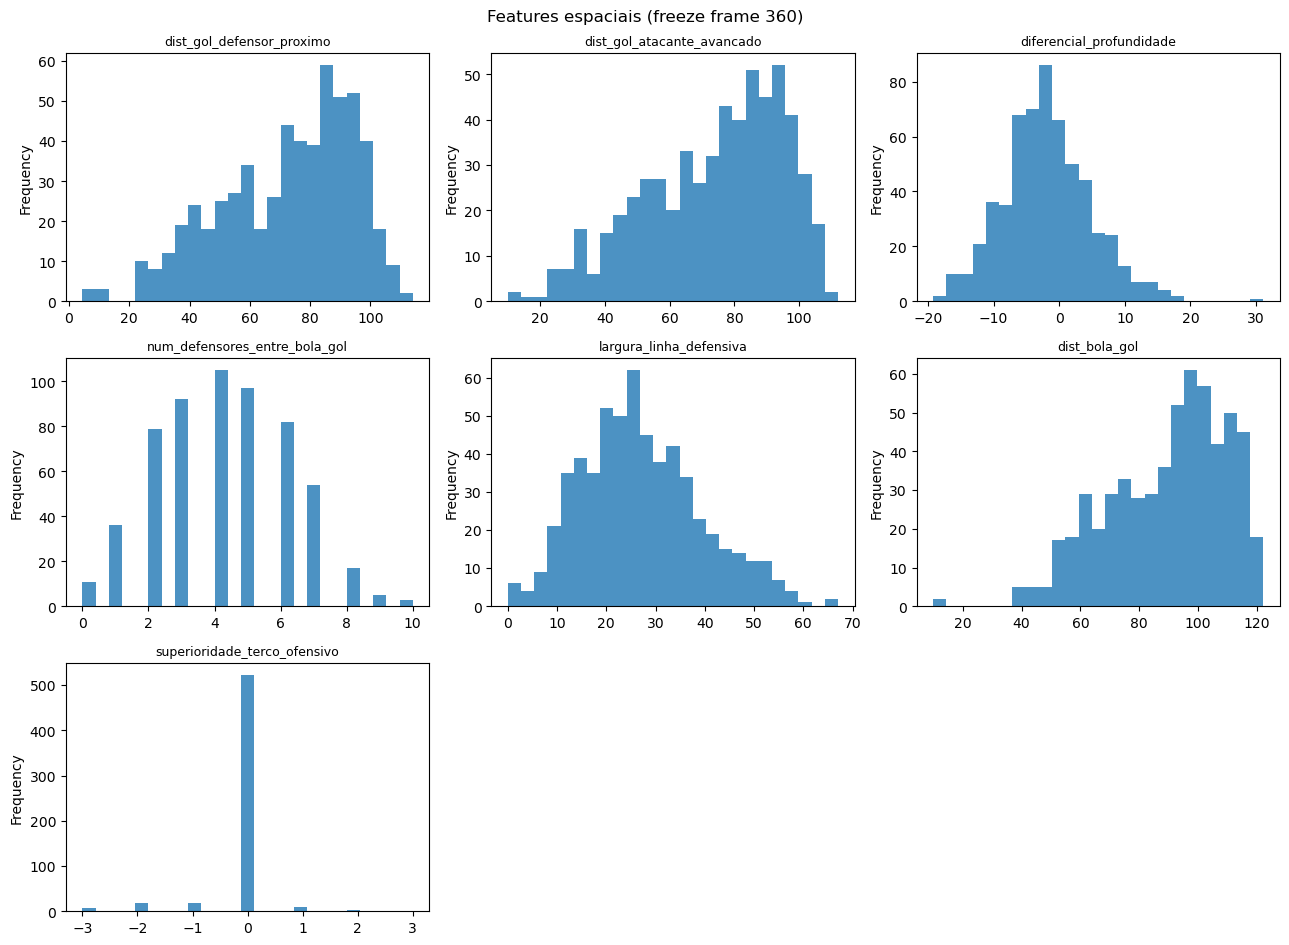

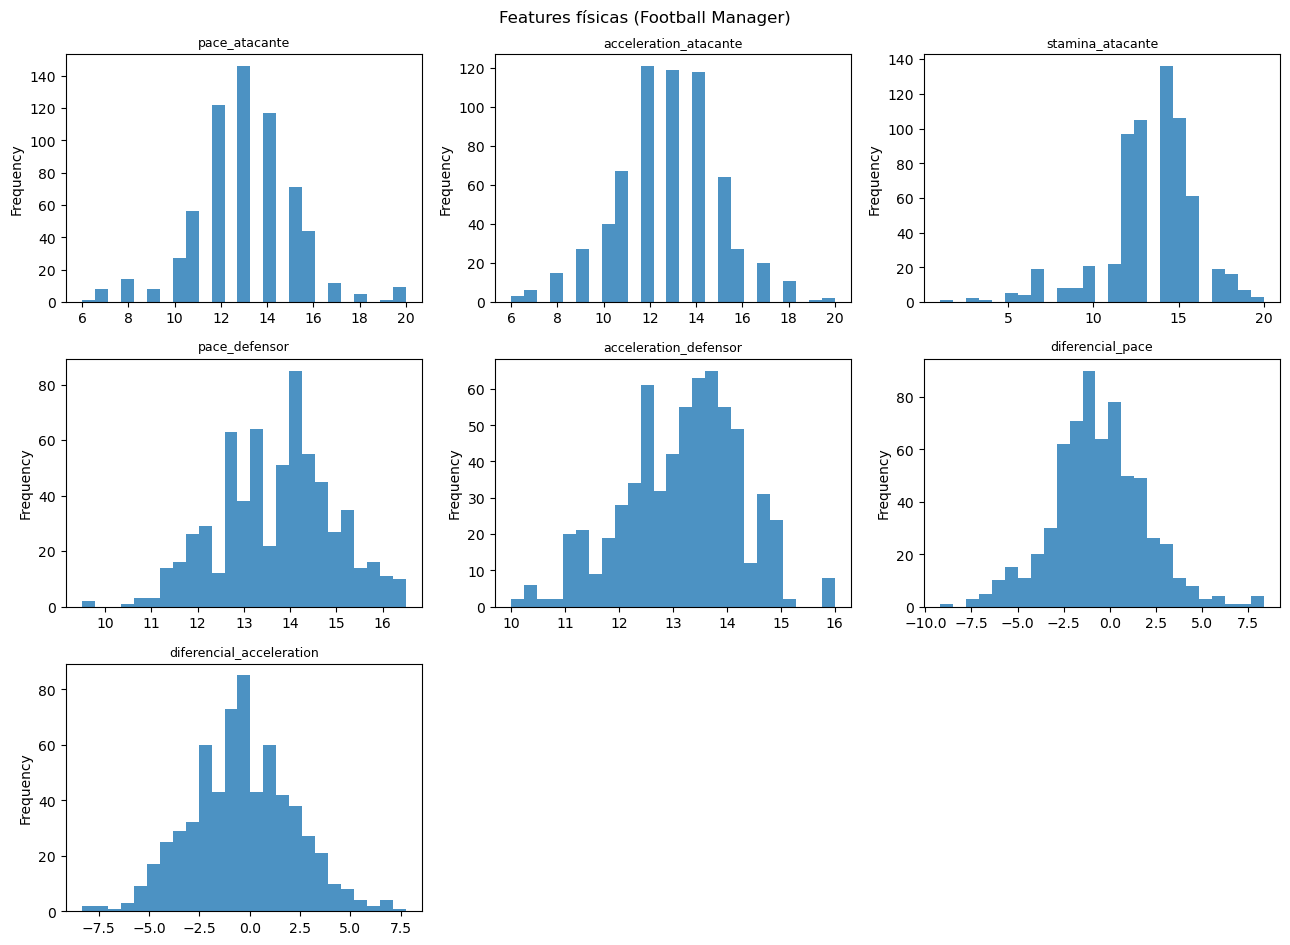

In [4]:
def grade_hist(cols, titulo):
    n = len(cols); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.2 * nrow))
    for ax, c in zip(axes.ravel(), cols):
        df[c].plot.hist(ax=ax, bins=25, color='#1f77b4', alpha=0.8)
        ax.set_title(c, fontsize=9)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.suptitle(titulo, fontsize=12); plt.tight_layout(); plt.show()

grade_hist(ESPACIAIS, 'Features espaciais (freeze frame 360)')
grade_hist(FISICAS, 'Features físicas (Football Manager)')

## 4. Features vs. alvo

Média de cada feature por classe e diferença relativa — quais separam sucesso de falha?

,media_falha,media_sucesso,dif,corr_ptbiserial
dist_bola_gol,90.982,81.482,-9.500,-0.170
dist_gol_defensor_proximo,73.658,66.021,-7.637,-0.125
dist_gol_atacante_avancado,74.972,68.338,-6.635,-0.113
acceleration_atacante,12.722,13.186,0.463,0.074
num_defensores_entre_bola_gol,4.289,3.889,-0.400,-0.073
diferencial_acceleration,-0.467,0.043,0.510,0.073
diferencial_profundidade,-1.671,-2.839,-1.168,-0.063
diferencial_pace,-0.670,-0.252,0.418,0.060
pace_defensor,13.727,13.561,-0.166,-0.049
pace_atacante,13.057,13.309,0.252,0.042


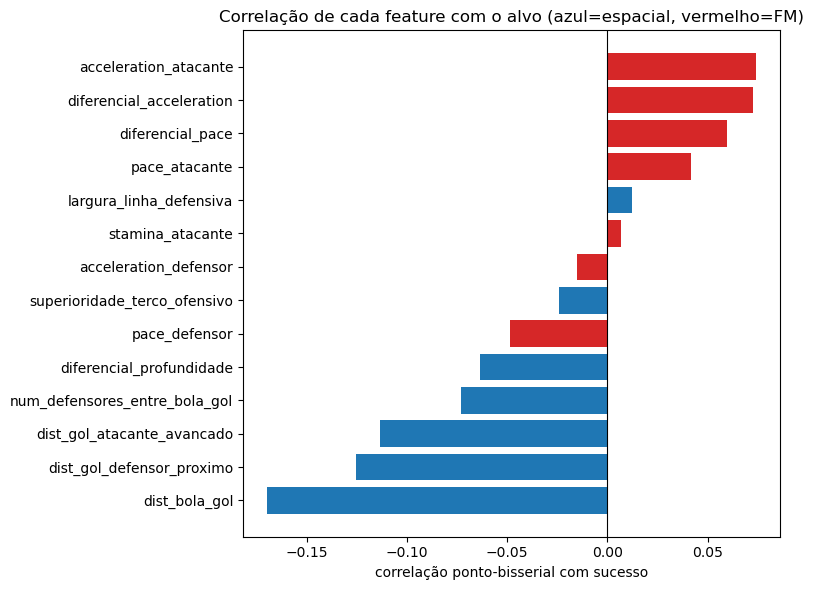

In [5]:
feats = ESPACIAIS + FISICAS
comp = df.groupby('sucesso')[feats].mean().T
comp.columns = ['media_falha', 'media_sucesso']
comp['dif'] = comp['media_sucesso'] - comp['media_falha']
comp['corr_ptbiserial'] = [df[f].corr(df['sucesso'].astype(float)) for f in feats]
display(comp.reindex(comp['corr_ptbiserial'].abs().sort_values(ascending=False).index).round(3))

fig, ax = plt.subplots(figsize=(8, 6))
cb = comp['corr_ptbiserial'].sort_values()
cores = ['#1f77b4' if f in ESPACIAIS else '#d62728' for f in cb.index]
ax.barh(cb.index, cb.values, color=cores)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Correlação de cada feature com o alvo (azul=espacial, vermelho=FM)')
ax.set_xlabel('correlação ponto-bisserial com sucesso')
plt.tight_layout(); plt.show()

## 5. Correlações entre features

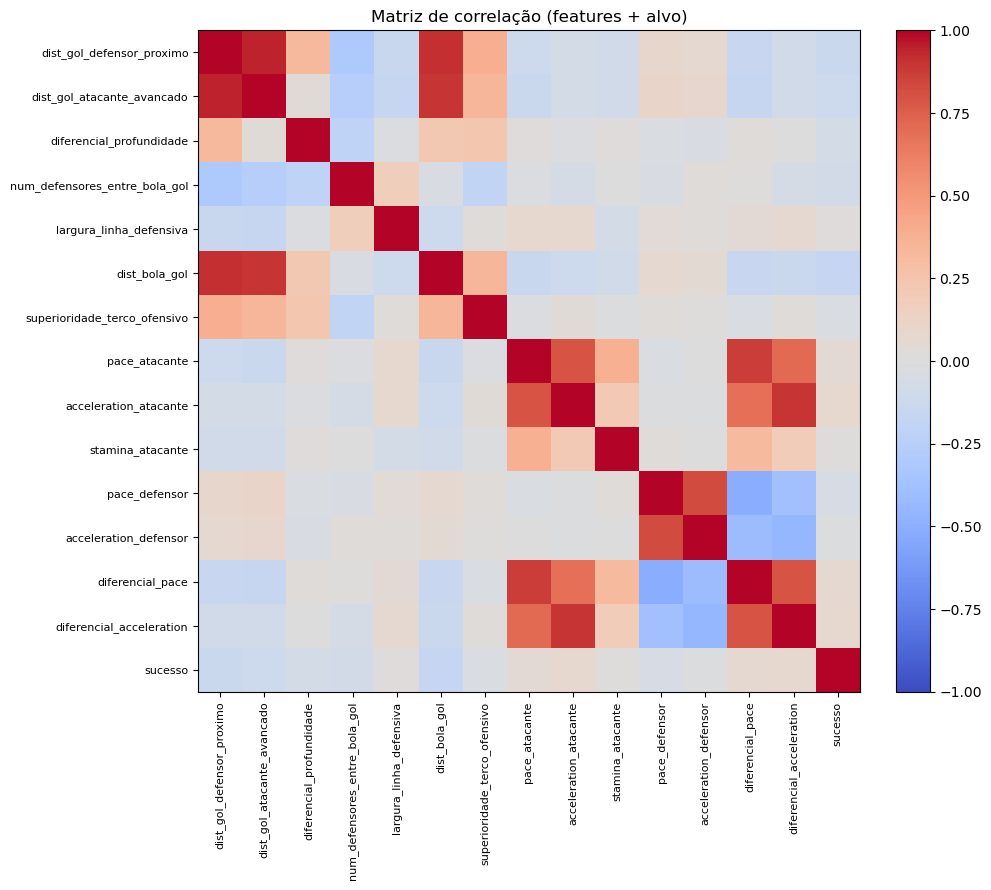

In [6]:
corr = df[feats + ['sucesso']].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Matriz de correlação (features + alvo)')
plt.tight_layout(); plt.show()

## 6. Qualidade dos dados — faltantes e qualidade do match com o FM

Valores faltantes por feature (apenas > 0):


,n_faltantes,pct
dist_gol_defensor_proximo,61,9.5
dist_gol_atacante_avancado,61,9.5
diferencial_profundidade,61,9.5
num_defensores_entre_bola_gol,61,9.5
largura_linha_defensiva,61,9.5
dist_bola_gol,61,9.5
superioridade_terco_ofensivo,61,9.5
pace_atacante,1,0.2
acceleration_atacante,1,0.2
stamina_atacante,1,0.2



Cobertura de features espaciais 360: 581/642

Qualidade do match FM (atac_fm_sim): média=0.906
Taxa de match do iniciador por competição:


competicao
Euro 2020          100.0
La Liga 2020/21    100.0
Ligue 1 2021/22    100.0
Ligue 1 2022/23    100.0
World Cup 2022      99.5
Name: atac_match_ok, dtype: float64

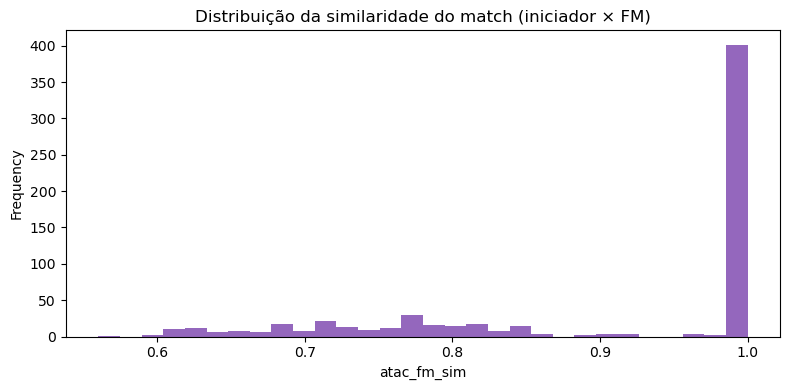

In [7]:
miss = df[feats].isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print('Valores faltantes por feature (apenas > 0):')
display(miss.to_frame('n_faltantes').assign(pct=(miss / len(df) * 100).round(1)))

print('\nCobertura de features espaciais 360:',
      f"{int(df['diferencial_profundidade'].notna().sum())}/{len(df)}")

if 'atac_fm_sim' in df.columns:
    print(f"\nQualidade do match FM (atac_fm_sim): média={df['atac_fm_sim'].mean():.3f}")
    if 'atac_match_ok' in df.columns:
        print('Taxa de match do iniciador por competição:')
        display((df.groupby('competicao')['atac_match_ok'].mean() * 100).round(1))
    fig, ax = plt.subplots(figsize=(8, 4))
    df['atac_fm_sim'].plot.hist(ax=ax, bins=30, color='#9467bd')
    ax.set_title('Distribuição da similaridade do match (iniciador × FM)')
    ax.set_xlabel('atac_fm_sim'); plt.tight_layout(); plt.show()

## 7. Features derivadas (engenharia) — prévia antes da modelagem

Criação das features propostas, que **fundem físico × espacial** e reduzem
redundância. Aqui só inspecionamos (distribuição e associação com o alvo); a
modelagem em si fica no notebook próprio.

| Feature | Fórmula | Ideia |
|---|---|---|
| `tempo_atac` | `dist_gol_atacante / pace_atacante` | tempo do atacante chegar ao gol |
| `corrida` | `dist_def/pace_def − dist_atac/pace_atac` | quem chega antes ao espaço |
| `vantagem` | `diferencial_profundidade × diferencial_pace` | à frente **E** mais rápido |
| `linha_quebrada` | `num_defensores_entre_bola_gol == 0` | não há defensor entre bola e gol |

In [8]:
eng = pd.DataFrame(index=df.index)
eng['tempo_atac']     = df['dist_gol_atacante_avancado'] / df['pace_atacante']
eng['corrida']        = (df['dist_gol_defensor_proximo'] / df['pace_defensor']
                         - df['dist_gol_atacante_avancado'] / df['pace_atacante'])
eng['vantagem']       = df['diferencial_profundidade'] * df['diferencial_pace']
eng['linha_quebrada'] = np.where(df['num_defensores_entre_bola_gol'].isna(), np.nan,
                                 (df['num_defensores_entre_bola_gol'] == 0).astype(float))

print('Resumo das features derivadas:')
display(eng.describe().T.round(3))
print('NaN por feature derivada:')
display(eng.isna().sum().to_frame('n_NaN').assign(pct=(eng.isna().mean()*100).round(1)))

Resumo das features derivadas:


,count,mean,std,min,25%,50%,75%,max
tempo_atac,580.0,5.861,2.157,0.834,4.28,5.860,7.205,14.447
corrida,580.0,-0.545,1.461,-8.090,-1.25,-0.371,0.365,3.287
vantagem,580.0,1.522,17.859,-143.993,-4.51,0.271,8.358,90.143
linha_quebrada,581.0,0.019,0.136,0.000,0.00,0.000,0.000,1.000


NaN por feature derivada:


,n_NaN,pct
tempo_atac,62,9.7
corrida,62,9.7
vantagem,62,9.7
linha_quebrada,61,9.5


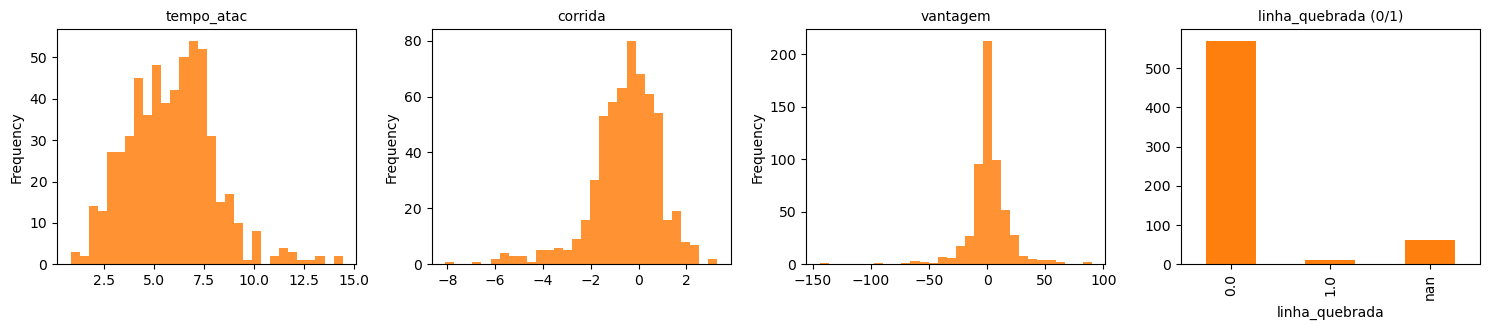

In [9]:
# Distribuições das features derivadas
cont = ['tempo_atac', 'corrida', 'vantagem']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, c in zip(axes[:3], cont):
    eng[c].plot.hist(ax=ax, bins=30, color='#ff7f0e', alpha=0.85)
    ax.set_title(c, fontsize=10)
eng['linha_quebrada'].value_counts(dropna=False).sort_index().plot.bar(
    ax=axes[3], color='#ff7f0e')
axes[3].set_title('linha_quebrada (0/1)', fontsize=10)
plt.tight_layout(); plt.show()

Top 12 por |correlação| com o alvo (derivadas marcadas [eng]):


,corr_alvo
[cru] dist_bola_gol,-0.170
[cru] dist_gol_defensor_proximo,-0.125
[cru] dist_gol_atacante_avancado,-0.113
[eng] vantagem,-0.112
[eng] tempo_atac,-0.101
[cru] acceleration_atacante,0.074
[cru] num_defensores_entre_bola_gol,-0.073
[cru] diferencial_acceleration,0.073
[cru] diferencial_profundidade,-0.063
[cru] diferencial_pace,0.060


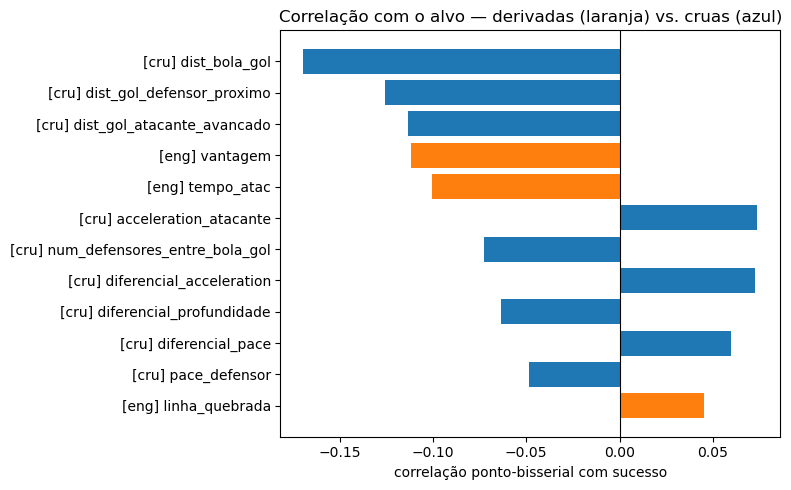

In [10]:
# Correlação com o alvo: derivadas vs. melhores cruas
y = df['sucesso'].astype(int)
corr_eng = {c: eng[c].corr(y.astype(float)) for c in eng.columns}
corr_raw = {c: df[c].corr(y.astype(float)) for c in (ESPACIAIS + FISICAS)}

comp = (pd.Series({**{f'[eng] {k}': v for k, v in corr_eng.items()},
                   **{f'[cru] {k}': v for k, v in corr_raw.items()}})
        .to_frame('corr_alvo'))
comp['abs'] = comp['corr_alvo'].abs()
comp = comp.sort_values('abs', ascending=False)
print('Top 12 por |correlação| com o alvo (derivadas marcadas [eng]):')
display(comp.head(12)[['corr_alvo']].round(3))

fig, ax = plt.subplots(figsize=(8, 5))
top = comp.head(12).iloc[::-1]
cores = ['#ff7f0e' if i.startswith('[eng]') else '#1f77b4' for i in top.index]
ax.barh(top.index, top['corr_alvo'], color=cores)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Correlação com o alvo — derivadas (laranja) vs. cruas (azul)')
ax.set_xlabel('correlação ponto-bisserial com sucesso')
plt.tight_layout(); plt.show()

In [11]:
# Médias das features derivadas por classe do alvo
comp_cls = eng.assign(sucesso=y).groupby('sucesso').mean().T
comp_cls.columns = ['media_falha', 'media_sucesso']
comp_cls['dif'] = comp_cls['media_sucesso'] - comp_cls['media_falha']
display(comp_cls.round(3))

,media_falha,media_sucesso,dif
tempo_atac,5.954,5.355,-0.599
corrida,-0.564,-0.445,0.119
vantagem,2.378,-3.142,-5.520
linha_quebrada,0.016,0.033,0.017


## 8. Observações

- Alvo bastante **desbalanceado** (~15% de sucesso) — relevante para a modelagem.
- Features físicas com `NaN` aparecem quando o iniciador/defensores não casaram no FM;
  espaciais com `NaN` quando a cadeia não tinha freeze frame 360.
- Use a seção 4 para ver quais features mais se associam ao `sucesso` antes de modelar.

> Lembrete: `xg_final` e `terminou_chute` **não** são features — definem o alvo
> (vazamento). Aqui aparecem apenas como contexto, não para modelagem.